In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_percentage_error

In [2]:
plt.style.use("seaborn-v0_8")

In [3]:
df = pd.read_csv("sales_time_series_dataset.csv")

df.head()

,date,sales
0,2022-01-01,186.16
1,2022-01-02,184.52
2,2022-01-03,208.87
3,2022-01-04,234.11
4,2022-01-05,221.25


In [4]:
df.shape

(912, 2)

In [5]:
df['date'] = pd.to_datetime(df['date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    912 non-null    datetime64[ns]
 1   sales   912 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 14.4 KB


In [7]:
df.describe()

,date,sales
count,912,912.000000
mean,2023-04-01 12:00:00,280.278191
min,2022-01-01 00:00:00,174.220000
25%,2022-08-16 18:00:00,238.300000
50%,2023-04-01 12:00:00,274.130000
75%,2023-11-15 06:00:00,315.655000
max,2024-06-30 00:00:00,413.950000
std,NaN,54.561749


In [8]:
df.isnull().sum()

date     0
sales    0
dtype: int64

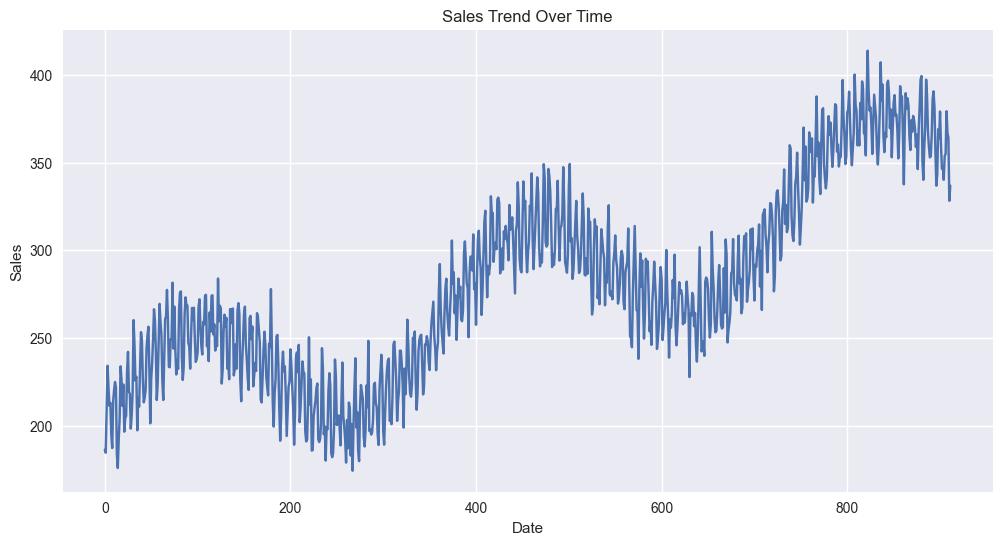

In [9]:
plt.figure(figsize=(12,6))

plt.plot(df['sales'])

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [10]:
df['rolling_mean'] = df['sales'].rolling(window=30).mean()

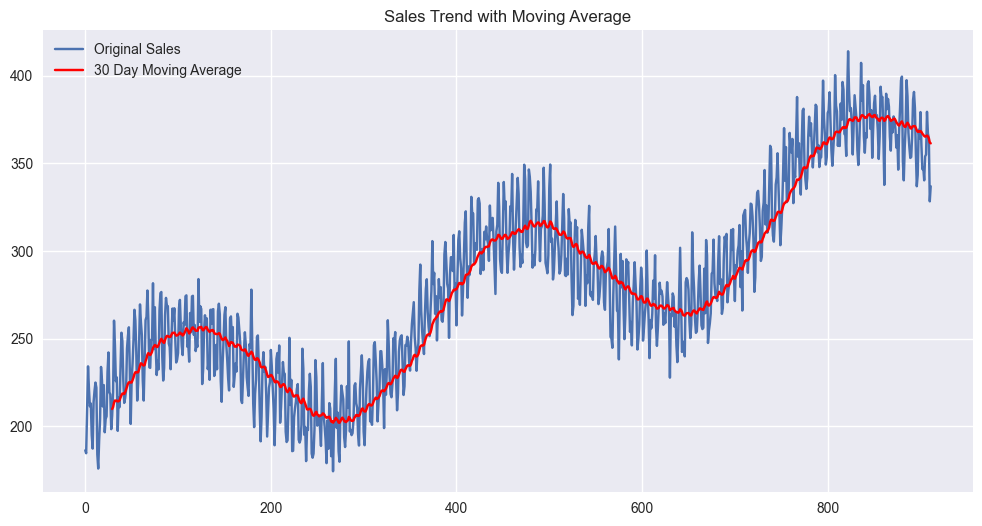

In [11]:
plt.figure(figsize=(12,6))

plt.plot(df['sales'], label="Original Sales")
plt.plot(df['rolling_mean'], color='red', label="30 Day Moving Average")

plt.legend()
plt.title("Sales Trend with Moving Average")

plt.show()

In [12]:
train = df[:-90]
test = df[-90:]

In [13]:
print(train.shape)
print(test.shape)

(822, 3)
(90, 3)


In [14]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [15]:
from statsmodels.tsa.arima.model import ARIMA

In [16]:
model = ARIMA(train['sales'], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  822
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3246.146
Date:                Sat, 14 Mar 2026   AIC                           6504.293
Time:                        11:43:23   BIC                           6532.556
Sample:                             0   HQIC                          6515.137
                                - 822                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5290      0.032    -16.779      0.000      -0.591      -0.467
ar.L2         -0.3399      0.026    -13.066      0.000      -0.391      -0.289
ar.L3         -0.4737      0.025    -19.176      0.0

In [17]:
forecast = model_fit.forecast(steps=90)

predictions = forecast

In [18]:
predictions.head()

822    394.405341
823    397.601364
824    385.994653
825    370.097076
826    361.169128
Name: predicted_mean, dtype: float64

In [19]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test['sales'], predictions)

print("MAPE:", mape)

MAPE: 0.04231869908852236


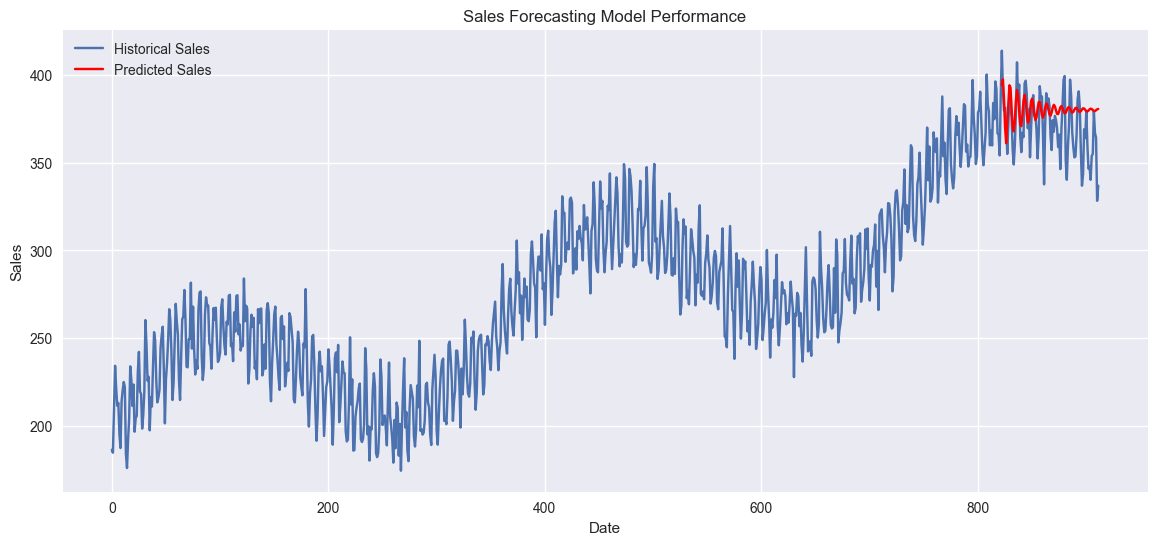

In [20]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['sales'], label="Historical Sales")
plt.plot(test.index, predictions, label="Predicted Sales", color="red")

plt.title("Sales Forecasting Model Performance")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.show()

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [22]:
decomposition = seasonal_decompose(df['sales'], model='additive', period=7)

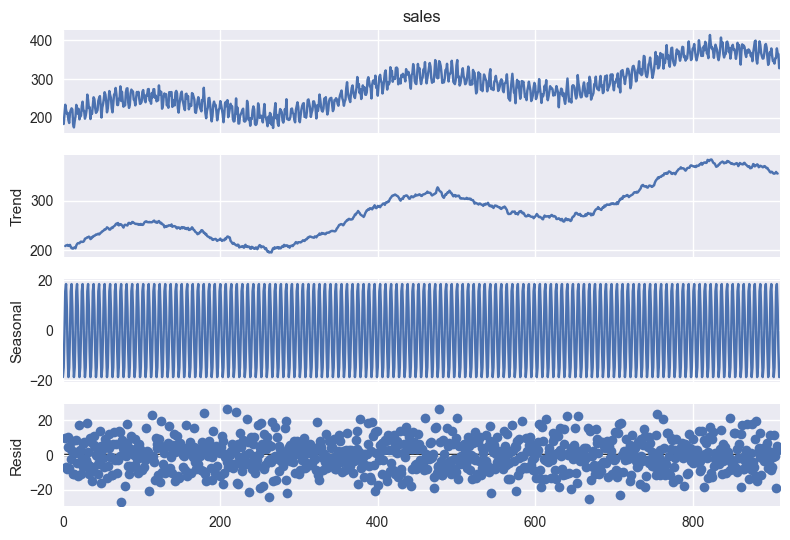

In [23]:
decomposition.plot()
plt.show()

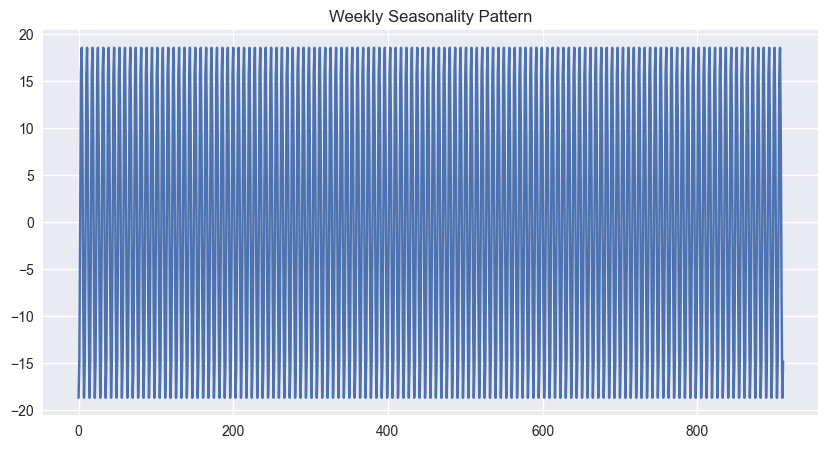

In [24]:
plt.figure(figsize=(10,5))

plt.plot(decomposition.seasonal)

plt.title("Weekly Seasonality Pattern")
plt.show()

In [25]:
window = 30

baseline_predictions = test['sales'].rolling(window).mean()
baseline_predictions = baseline_predictions.fillna(method='bfill')

C:\Users\rishi\AppData\Local\Temp\ipykernel_11900\3295509699.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  baseline_predictions = baseline_predictions.fillna(method='bfill')


In [26]:
baseline_mape = mean_absolute_percentage_error(test['sales'], baseline_predictions)

print("Baseline MAPE:", baseline_mape)

Baseline MAPE: 0.03547404317370588


In [27]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 932.9 kB/s eta 0:00:13
   -- ------------------------------------- 0.8/12.1 MB 1.1 MB/s eta 0:00:11
   --- ------------------------------------ 1.0/12.1 MB 1.1 MB/s eta 0:00:11
   ---- ----------------------------------- 1.3/12.1 MB 1.1 MB/s eta 0:00:10
   ----- ---------------------------------- 1.6/12.1 MB 1.1 MB/s eta 0:00:10
   ------ --------------------------------- 1.8/12.1 MB 1.1 MB/s eta 0:00:09
   ------ --------------------------------- 2.1/12.1 MB 1.2 MB/s eta 0:00:09
   ------- -------------------------------- 2.4/12.1 MB 1.2 MB/s eta 0:00:09
   -------- ------------------------------- 2.6/12.1 MB 1.2 MB/s eta 0:00:09
   --------- ------------------------------ 2.9/12.1 MB 1.2 MB/s eta 0:00:08
   ---------- ----

In [30]:
from prophet import Prophet

In [32]:
prophet_df = df.reset_index()[['date','sales']]
prophet_df.columns = ['ds','y']

prophet_df.head()

,ds,y
0,2022-01-01,186.16
1,2022-01-02,184.52
2,2022-01-03,208.87
3,2022-01-04,234.11
4,2022-01-05,221.25


In [33]:
from prophet import Prophet

model = Prophet()

model.fit(prophet_df)

11:48:56 - cmdstanpy - INFO - Chain [1] start processing
11:48:57 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

forecast[['ds','yhat']].tail()

,ds,yhat
997,2024-09-24,342.690906
998,2024-09-25,345.512033
999,2024-09-26,335.895584
1000,2024-09-27,318.697335
1001,2024-09-28,308.346365


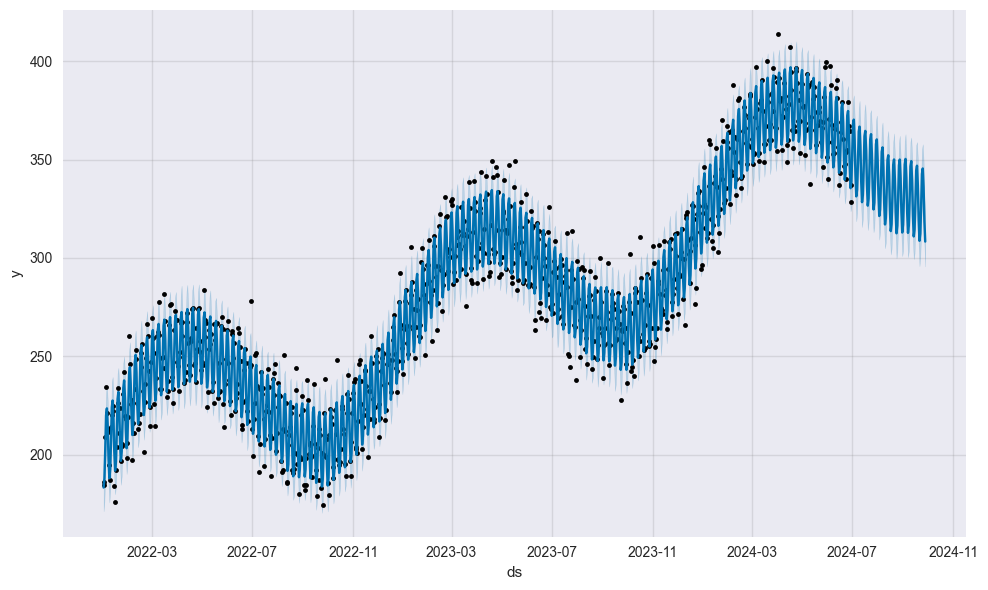

In [35]:
model.plot(forecast)
plt.show()

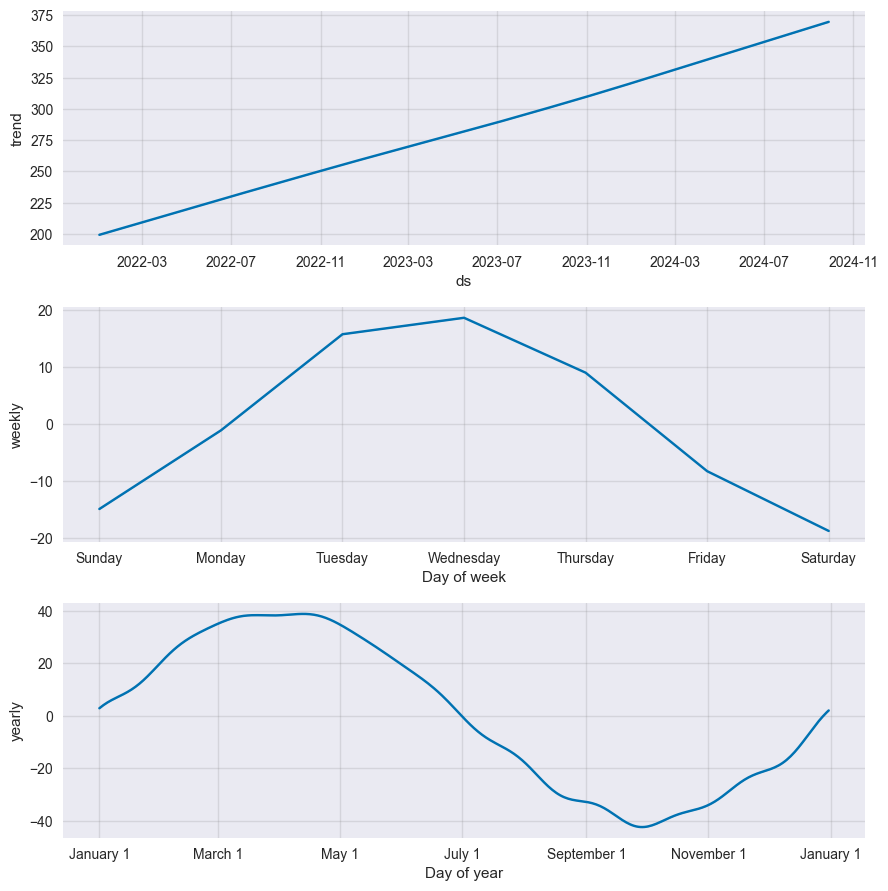

In [36]:
model.plot_components(forecast)
plt.show()